In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3 # context length: how many characters do we take to predict the next one?
  
X, Y = [], []
for w in words[:5]:

    #print(w)
    context = [0] * block_size
    for ch in w + '.': # always padding with dots
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)


... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
... ---> a
..a ---> v
.av ---> a
ava ---> .
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .
torch.Size([32, 3]) torch.Size([32])


In [6]:
X.shape, X.dtype, Y.shape,Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
C=torch.randn((27,2))


In [8]:
emb=C[X]
emb.shape

torch.Size([32, 3, 2])

In [9]:
# F.one_hot(torch.tensor(5),num_classes=27).float() @ C
# must be tensor not an int
# embedding of the integer can be thought of as either indexing into a lookup table C or as a first layer(linear) of a bigger neural net and their weight matrix is C and encoding integers in one hot and the first layer embeds them
# using index here because its faster

In [10]:
# C[torch.tensor([5,6,7,7,6])]
C[X].shape

torch.Size([32, 3, 2])

In [11]:
W1=torch.randn((3*2,100)) # 6= 3*2 which are the other two dimensions of emb
b1=torch.randn(100)

In [12]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape # need to specify index mannualy

torch.Size([32, 6])

In [13]:
torch.unbind(emb,1) #gives list of tensors removing index 1

(tensor([[-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5294,  0.6835],
         [ 0.9761, -0.8329],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.2318, -0.8832],
         [-0.5120, -0.2395],
         [ 0.4757, -0.5462],
         [ 1.1648,  0.1341],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.7407, -0.2259],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [ 0.4757, -0.5462],
         [-1.6696, -0.4348],
         [-0.7407, -0.2259],
         [ 1.7750,  0.2986],
         [-0.5294,  0.6835],
         [-0.5120, -0.2395],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-1.6696, -0.4348],
         [-0.2318, -0.8832],
         [-2.0334, -2.9676],
         [-1.1452, -0.8428]]),
 tensor([[-0.5635, -0.8353],
         [-0.5635, -0.8353],
         [-0

In [14]:
# so to concatenate without mentioning index manually
torch.cat(torch.unbind(emb,1),1) # inefficient as it creates a new tensor which takes up extra memory. 
#got the same result

tensor([[-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5294,  0.6835],
        [-0.5635, -0.8353, -0.5294,  0.6835,  0.9761, -0.8329],
        [-0.5294,  0.6835,  0.9761, -0.8329,  0.9761, -0.8329],
        [ 0.9761, -0.8329,  0.9761, -0.8329, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.2318, -0.8832],
        [-0.5635, -0.8353, -0.2318, -0.8832, -0.5120, -0.2395],
        [-0.2318, -0.8832, -0.5120, -0.2395,  0.4757, -0.5462],
        [-0.5120, -0.2395,  0.4757, -0.5462,  1.1648,  0.1341],
        [ 0.4757, -0.5462,  1.1648,  0.1341,  0.4757, -0.5462],
        [ 1.1648,  0.1341,  0.4757, -0.5462, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.7407, -0.2259,  1.1648,  0.1341],
        [-0.7407, -0.2259,  1.1648,  0.1

In [15]:
a=torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [16]:
a.view(2,9) # change the interpretation of a without changing the storage or properties

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [17]:
a.view(3,3,2) # 3*3*2=18

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [18]:
a.storage() # always stored as 1d

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_18292\3374686626.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage() # always stored as 1d


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [19]:
emb.view(32,6) # easiest using torch internals

tensor([[-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5294,  0.6835],
        [-0.5635, -0.8353, -0.5294,  0.6835,  0.9761, -0.8329],
        [-0.5294,  0.6835,  0.9761, -0.8329,  0.9761, -0.8329],
        [ 0.9761, -0.8329,  0.9761, -0.8329, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.2318, -0.8832],
        [-0.5635, -0.8353, -0.2318, -0.8832, -0.5120, -0.2395],
        [-0.2318, -0.8832, -0.5120, -0.2395,  0.4757, -0.5462],
        [-0.5120, -0.2395,  0.4757, -0.5462,  1.1648,  0.1341],
        [ 0.4757, -0.5462,  1.1648,  0.1341,  0.4757, -0.5462],
        [ 1.1648,  0.1341,  0.4757, -0.5462, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.5635, -0.8353],
        [-0.5635, -0.8353, -0.5635, -0.8353, -0.7407, -0.2259],
        [-0.5635, -0.8353, -0.7407, -0.2259,  1.1648,  0.1341],
        [-0.7407, -0.2259,  1.1648,  0.1

In [20]:
h=torch.tanh(emb.view(-1,6)@ W1 + b1) 
# 100 d activations of 32 examples
# -1 makes pytorch infer that number given the other numbers

In [21]:
h

tensor([[ 0.9990, -0.4792, -0.8058,  ...,  0.5932, -0.3806,  0.7993],
        [ 0.9941,  0.1298, -0.9846,  ..., -0.9123,  0.9478,  0.9978],
        [ 0.9695, -0.8291, -0.9976,  ...,  0.7931, -0.8654,  0.8778],
        ...,
        [ 1.0000, -0.6855,  0.7236,  ...,  0.8885, -0.0691,  0.9015],
        [ 0.9998, -0.9999, -1.0000,  ..., -0.9710, -0.9554,  0.9999],
        [ 0.9737, -0.2470, -0.9257,  ..., -0.9566,  0.0012,  0.7421]])

In [22]:
b1.shape
# 32*100
# 1*100 copied 32 times that is same bias added to all rows which is what we want

torch.Size([100])

In [23]:
#output layer
W2 = torch.randn((100,27)) # previous layer , output alphabets 
b2=torch.randn(27)

In [24]:
logits =h @ W2 +b2

In [25]:
logits.shape

torch.Size([32, 27])

In [ ]:
# counts=logits.exp()
# probs=counts/counts.sum(1,keepdim=True)

In [ ]:
# probs.shape

torch.Size([32, 27])

In [ ]:
# probs[0].sum() # means normalised

tensor(1.)

In [ ]:
# loss=-probs[torch.arange(32),Y].log().mean()
# loss

tensor(17.8941)

In [ ]:
# loss= F.cross_entropy(logits,Y) 
#this is the same loss but much more efficient
# no intermediate tensors made that is they run in a fused kernel and mathematically it takes a much simpler form
# manually getting logits is bad for large numbers too it subtracts the largest number


In [30]:
# cleaned version

In [129]:
block_size = 3 # context length: how many characters do we take to predict the next one?
  
X, Y = [], []
for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.': # always padding with dots
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
    #   print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [130]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [131]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [132]:
for p in parameters:
    p.requires_grad=True

In [ ]:
for _ in range (10):
    #forward pass 
    emb = C[X]
    h=torch.tanh(emb.view(-1,6)@ W1 + b1) 
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    for p in parameters:
        p.data+= -0.1*p.grad 

6.795017242431641
6.676602363586426
6.563317775726318
6.454789161682129
6.350668430328369
6.250642776489258
6.154431343078613
6.061785697937012
5.972482204437256
5.886327743530273


In [80]:
# using batching now to make it more efficient 


In [119]:
# find a good learning rate
lre =torch.linspace(-3,0,1000) # learning rate exponent
lrs= 10** lre
# lrs

In [ ]:
# lri=[]
# lossi=[]
for _ in range (10000):
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,) ) # needs a tupple for number of samples
    # forward pass
    emb = C[X[ix]] # 32,3,2
    h=torch.tanh(emb.view(-1,6)@ W1 + b1) 
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.1 # learning rate decay after running for some instances
    for p in parameters:
        p.data+= -lr*p.grad 
    # # track stats
    # lri.append(lre[_]) # now x axis will be exp of the learning rate
    # lossi.append(loss.item())
print(loss.item())

2.301748752593994


In [139]:
# plt.plot(lri,lossi) # plot shows that a good learning rate is around -1 which is 10**-1 so remove tracking and just make that the learning rate

In [ ]:
emb = C[X] # 32,3,2
h=torch.tanh(emb.view(-1,6)@ W1 + b1) 
logits= h @ W2 + b2
loss= F.cross_entropy(logits,Y)
loss
# overfitting will cause sampling to return only the names already in the dataset so we will use splits

tensor(2.4281, grad_fn=<NllLossBackward0>)

In [ ]:
# training split, validation split, test split (80,10,10)
# training set is used for tuning the model with parameters like here using gradient descent
# validation/ dev split is used for hyperparameters like size of hidden layer, size of embeddings and so on
# test split is used for validation and allowed to test very few times otherwise it will leak data

In [142]:
# finally with everything included

In [144]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # n1 words for training 
Xdev, Ydev = build_dataset(words[n1:n2]) # n2-n1 for validation
Xte, Yte = build_dataset(words[n2:]) # total -n2 for test

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [186]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [203]:
# same code as above
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((3*10, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [204]:
sum(p.nelement() for p in parameters) 

11897

In [205]:
for p in parameters:
    p.requires_grad=True

In [206]:
lri=[]
lossi=[]
stepi=[]

In [ ]:

for i in range (50000):
    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (32,) ) # batch size might be too small that it adds too much noise to the network
    # forward pass
    emb = C[Xtr[ix]] # we might be cramming too much in 2 d 
    h=torch.tanh(emb.view(-1,30)@ W1 + b1) 
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.01
    for p in parameters:
        p.data+= -lr*p.grad 
    # track stats    
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

1.5759177207946777


In [207]:

# more production like code the same thing but not changing lr manually 
for i in range (200000):
    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (32,) ) # batch size might be too small that it adds too much noise to the network
    # forward pass
    emb = C[Xtr[ix]] # we might be cramming too much in 2 d 
    h=torch.tanh(emb.view(-1,30)@ W1 + b1) 
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.1 if i <100000 else 0.01
    for p in parameters:
        p.data+= -lr*p.grad 
    # track stats    
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

2.178402900695801


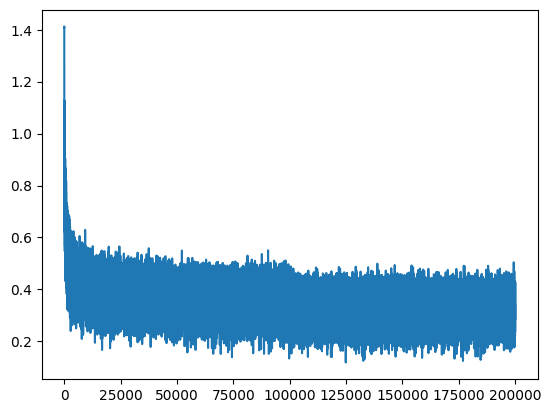

In [208]:
plt.plot(stepi,lossi) # this is thick because the mini batch size is very small

In [209]:
emb = C[Xtr] # 32,3,2
h=torch.tanh(emb.view(-1,30)@ W1 + b1) 
logits= h @ W2 + b2
loss= F.cross_entropy(logits,Ytr)
loss

tensor(2.1176, grad_fn=<NllLossBackward0>)

In [210]:
# use dev set to evaluate
emb = C[Xdev] 
h=torch.tanh(emb.view(-1,30)@ W1 + b1) 
logits= h @ W2 + b2
loss= F.cross_entropy(logits,Ydev)
loss.item() # now its better than earlier caused by increase in dimension of embedding and we made the hidden layer of 200 neurons than 300 

2.1612696647644043

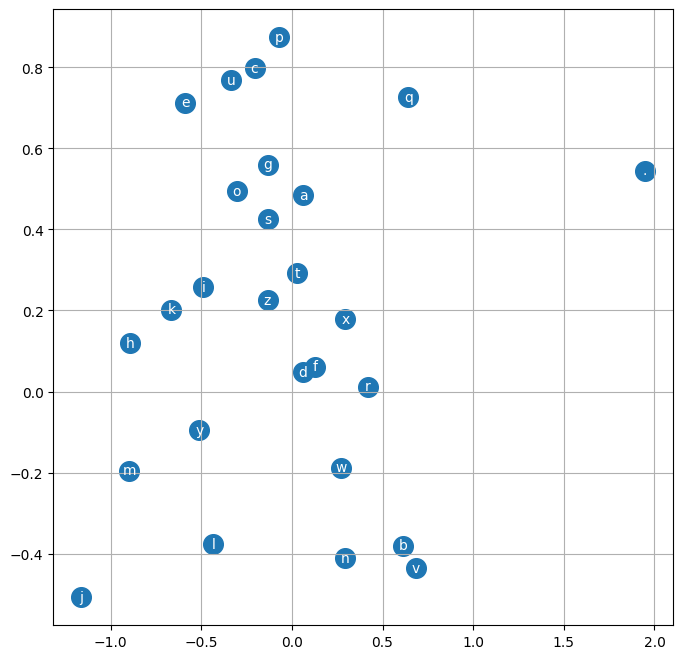

In [211]:
# visualising embeddings
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [212]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))


carlah.
amorie.
khirmri.
reety.
skanden.
jazhnen.
den.
rha.
kaqeicee.
mara.
chaihvik.
leigh.
ham.
pore.
quinn.
suline.
liveni.
wajeron.
jaryxia.
kael.
